Install packages

In [1]:
!pip install rdkit pandas numpy matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 48.9 MB/s eta 0:00:00:00:0100:01


Clone the repo

In [2]:
import os
REPO_ROOT = "/content/REINVENT_Boltz_Pipeline"
if not os.path.exists(REPO_ROOT):
    !git clone https://github.com/ibrahimwichka/REINVENT_Boltz_Pipeline.git {REPO_ROOT}
else:
    !git -C {REPO_ROOT} pull origin main
print(os.path.exists(REPO_ROOT))

Cloning into '/content/REINVENT_Boltz_Pipeline'...
remote: Enumerating objects: 111, done.
remote: Counting objects: 100% (111/111), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 111 (delta 33), reused 85 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (111/111), 21.82 MiB | 19.51 MiB/s, done.
Resolving deltas: 100% (33/33), done.
True


Setting target and pointing at the data

In [3]:
from pathlib import Path
# --- The only two lines that change between your two notebooks ---
TARGET_NAME = "CDK2" # or "P38_MAPK14"
DATA_FILENAME = "CDK2_Actives_CHEMBL_Bioactivities.csv" 
# or "P38_MAPK_Actives_CHEMBL_Bioactivities.csv"
# -------------------------------------------------------------------
REPO_ROOT_PATH = Path(REPO_ROOT)
DATA_PATH = REPO_ROOT_PATH / "target_mols" / TARGET_NAME / "IC50" / DATA_FILENAME
ANALYSIS_DIR = REPO_ROOT_PATH / "target_mols" / TARGET_NAME / "analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

print(DATA_PATH.exists())
print(ANALYSIS_DIR)

True
/content/REINVENT_Boltz_Pipeline/target_mols/CDK2/analysis


Imports

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, Crippen, Lipinski, QED, rdMolDescriptors
from rdkit.Chem import rdFingerprintGenerator, rdRGroupDecomposition
from rdkit.Chem.Scaffolds import MurckoScaffold

sns.set_theme(style="whitegrid")

Loading and inspecting known-actives data

In [5]:
raw = pd.read_csv(DATA_PATH, sep=None, engine="python")
print(TARGET_NAME, raw.shape)
print(raw.columns.tolist())
raw.head()

CDK2 (1402, 4)
['Molecule ChEMBL ID', 'Smiles', 'IC50_nM', 'pIC50']


,Molecule ChEMBL ID,Smiles,IC50_nM,pIC50
0,CHEMBL526110,O=[N+]([O-])c1cccc(Nc2nccc(-c3cnn4ncccc34)n2)c1,0.30,9.52
1,CHEMBL317703,NS(=O)(=O)c1ccc(Nc2cc(-c3ccc([N+](=O)[O-])cc3)...,0.33,9.48
2,CHEMBL321517,Nc1ccc(-c2cc(Nc3ccc(S(N)(=O)=O)cc3)[nH]n2)cc1,0.34,9.47
3,CHEMBL388978,CN[C@@H]1C[C@H]2O[C@@](C)([C@@H]1OC)n1c3ccccc3...,0.36,9.44
4,CHEMBL476577,CC(=O)NC1CN(c2ccc(Nc3ncc(F)c(-c4cnc(C)n4C(C)C)...,0.50,9.30


In [6]:
print([c for c in raw.columns if "smiles" in c.lower()])
print([c for c in raw.columns if "chembl value" in c.lower() or "standard value" in c.
lower()])

['Smiles']
[]


Cleaning and canonicalizing SMILES

In [7]:
def canonicalize(smiles):
    """Return a canonical SMILES string, or None if RDKit can’t parse it."""
    if not isinstance(smiles, str) or not smiles.strip():
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol)

def clean_actives(df_raw, smiles_col):
    df = df_raw.copy()
    df["canonical_smiles"] = df[smiles_col].apply(canonicalize)
    n_before = len(df)
    df = df.dropna(subset=["canonical_smiles"])
    df = df.drop_duplicates(subset=["canonical_smiles"]).reset_index(drop=True)
    print(f"kept {len(df)} of {n_before} rows after canonicalization + dedup")
    return df

df = clean_actives(raw, smiles_col="Smiles")    # adjust column name if yours differs

kept 1402 of 1402 rows after canonicalization + dedup


Lipinski/drug-likeness descriptors and visualization

In [8]:
def add_descriptors(df):
    mols = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]
    df = df.copy()
    df["MW"] = [Descriptors.MolWt(m) for m in mols]
    df["cLogP"] = [Crippen.MolLogP(m) for m in mols]
    df["HBD"] = [Lipinski.NumHDonors(m) for m in mols]
    df["HBA"] = [Lipinski.NumHAcceptors(m) for m in mols]
    df["TPSA"] = [rdMolDescriptors.CalcTPSA(m) for m in mols]
    return df

df = add_descriptors(df)
df[["MW", "cLogP", "HBD", "HBA", "TPSA"]].describe()

,MW,cLogP,HBD,HBA,TPSA
count,1402.000000,1402.000000,1402.000000,1402.000000,1402.000000
mean,426.665373,3.580727,2.327389,5.972896,96.115606
std,80.074682,1.256354,1.054790,1.690332,23.761838
min,144.137000,-0.831230,0.000000,1.000000,44.290000
25%,371.441500,2.785800,2.000000,5.000000,80.050000
50%,427.510500,3.635300,2.000000,6.000000,95.160000
75%,476.531250,4.443070,3.000000,7.000000,110.960000
max,885.011000,8.646000,7.000000,12.000000,195.320000


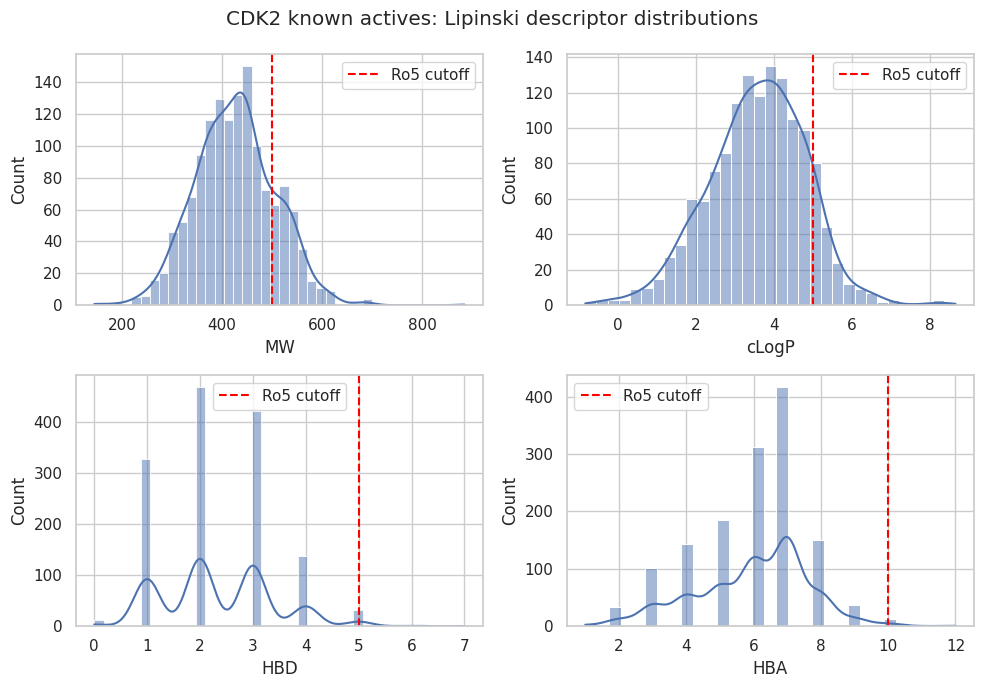

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, col, ro5_cutoff in zip(
    axes.flat, ["MW", "cLogP", "HBD", "HBA"], [500, 5, 5, 10]
    ):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.axvline(ro5_cutoff, color="red", linestyle="--", label="Ro5 cutoff")
    ax.legend()
fig.suptitle(f"{TARGET_NAME} known actives: Lipinski descriptor distributions")
fig.tight_layout()
fig.savefig(ANALYSIS_DIR / f"{TARGET_NAME}_lipinski_distributions.png", dpi=150,
    bbox_inches="tight")
plt.show()

QED 

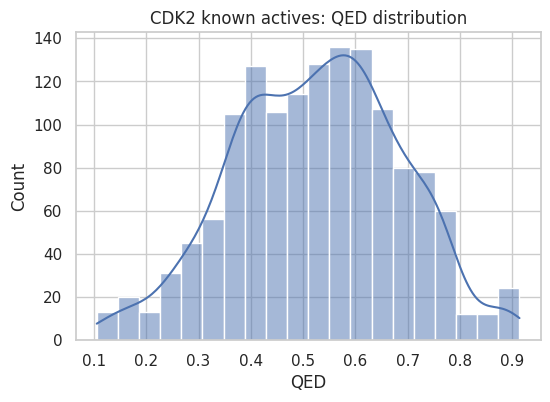

In [10]:
def add_qed(df):
    mols = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]
    df = df.copy()
    df["QED"] = [QED.qed(m) for m in mols]
    return df

df = add_qed(df)

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(data=df, x="QED", kde=True, ax=ax)
ax.set_title(f"{TARGET_NAME} known actives: QED distribution")
fig.savefig(ANALYSIS_DIR / f"{TARGET_NAME}_qed_distribution.png", dpi=150, bbox_inches=
    "tight")
plt.show()

Synthetic accessibility (SA) score

In [11]:
!mkdir -p /content/sa_score
!curl -L -o /content/sa_score/sascorer.py \
    https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py
!curl -L -o /content/sa_score/fpscores.pkl.gz \
    https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  5913  100  5913    0     0  24511      0 --:--:-- --:--:-- --:--:-- 24535
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 3758k  100 3758k    0     0  4741k      0 --:--:-- --:--:-- --:--:-- 4739k


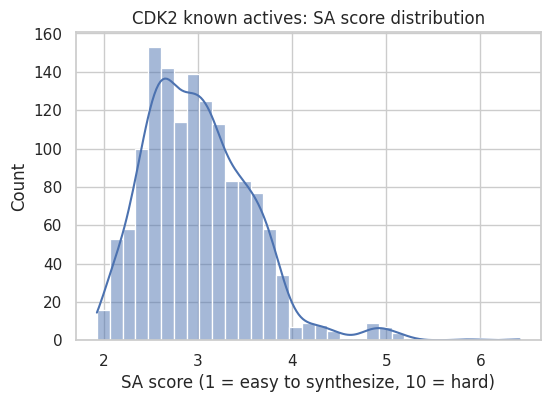

In [12]:
import sys
sys.path.append("/content/sa_score")
import sascorer # only works after the notebox cell above

def add_sa_score(df):
    mols = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]
    df = df.copy()
    df["SA_score"] = [sascorer.calculateScore(m) for m in mols]
    return df

df = add_sa_score(df)

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(data=df, x="SA_score", kde=True, ax=ax)
ax.set_xlabel("SA score (1 = easy to synthesize, 10 = hard)")
ax.set_title(f"{TARGET_NAME} known actives: SA score distribution")
fig.savefig(ANALYSIS_DIR / f"{TARGET_NAME}_sa_score_distribution.png", dpi=150,
    bbox_inches="tight")
plt.show()

Murcko scaffold diversity

CDK2 unique scaffolds: 603 of 1402 molecules


/tmp/ipykernel_718/3187241411.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


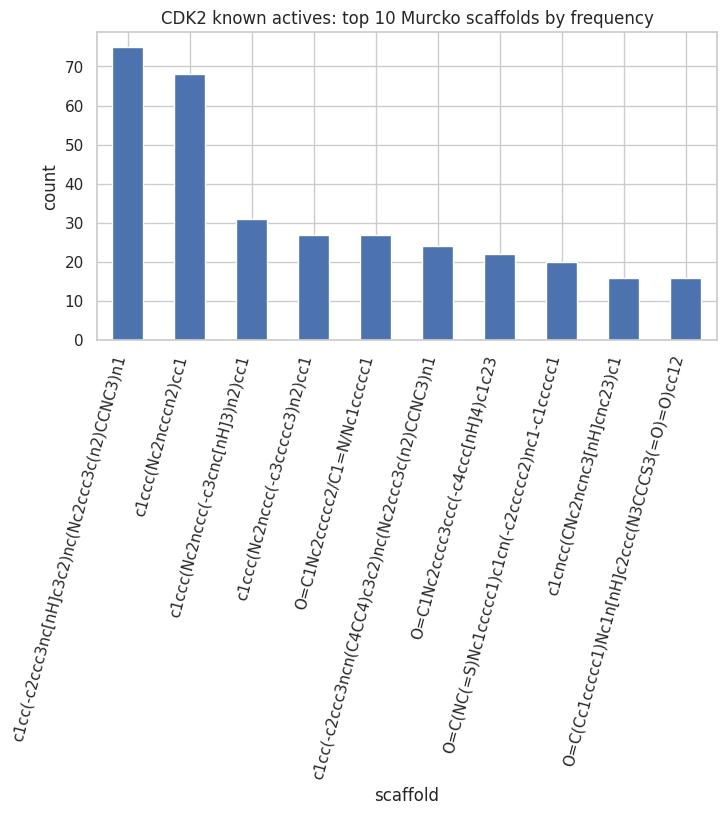

In [13]:
def add_scaffold(df):
    mols = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]
    df = df.copy()
    df["scaffold"] = [
    Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(m)) for m in mols
    ]
    return df

df = add_scaffold(df)

print(f"{TARGET_NAME} unique scaffolds:", df["scaffold"].nunique(), "of", len(df), 
    "molecules")

top_scaffolds = df["scaffold"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(8, 4))
top_scaffolds.plot(kind="bar", ax=ax)
ax.set_ylabel("count")
ax.set_title(f"{TARGET_NAME} known actives: top 10 Murcko scaffolds by frequency")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
fig.savefig(ANALYSIS_DIR / f"{TARGET_NAME}_top_scaffolds.png", dpi=150, bbox_inches=
    "tight")
plt.show()

Functional group frequency (SMARTS)

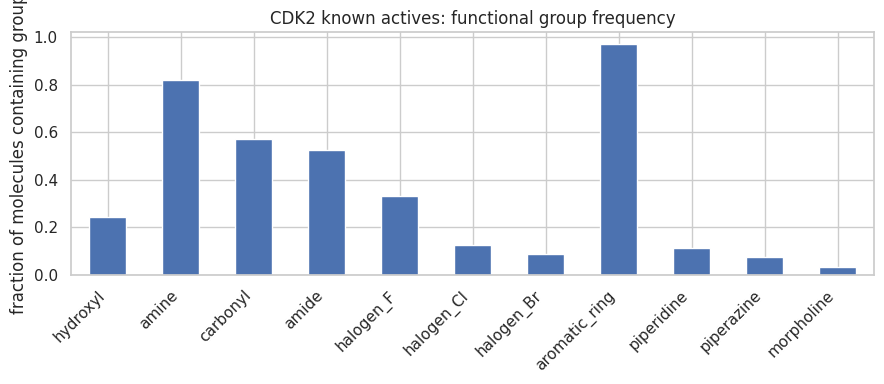

In [14]:
FUNCTIONAL_GROUP_SMARTS = {
    "hydroxyl": "[OX2H]",
    "amine": "[NX3;H2,H1;!$(NC=O)]",
    "carbonyl": "[CX3]=[OX1]",
    "amide": "C(=O)N",
    "halogen_F": "[#9]",
    "halogen_Cl": "[#17]",
    "halogen_Br": "[#35]",
    "aromatic_ring": "a1aaaaa1",
    "piperidine": "C1CCNCC1",
    "piperazine": "C1CNCCN1",
    "morpholine": "C1COCCN1",
    }
FUNCTIONAL_GROUP_PATTERNS = {
    name: Chem.MolFromSmarts(smarts) for name, smarts in FUNCTIONAL_GROUP_SMARTS.items()
    }

def add_functional_group_flags(df):
    mols = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]
    df = df.copy()
    for name, patt in FUNCTIONAL_GROUP_PATTERNS.items():
        df[f"has_{name}"] = [m.HasSubstructMatch(patt) for m in mols]
    return df

df = add_functional_group_flags(df)

flag_cols = [f"has_{name}" for name in FUNCTIONAL_GROUP_SMARTS]
freq = df[flag_cols].mean()
freq.index = [c.replace("has_", "") for c in freq.index]

fig, ax = plt.subplots(figsize=(9, 4))
freq.plot(kind="bar", ax=ax)
ax.set_ylabel("fraction of molecules containing group")
ax.set_title(f"{TARGET_NAME} known actives: functional group frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(ANALYSIS_DIR / f"{TARGET_NAME}_functional_group_frequency.png", dpi=150,
    bbox_inches="tight")
plt.show()

R-group decomposition

In [15]:
top_scaffold_smiles = df["scaffold"].value_counts().index[0]
core = Chem.MolFromSmiles(top_scaffold_smiles)

subset = df[df["scaffold"] == top_scaffold_smiles].reset_index(drop=True)
mols = [Chem.MolFromSmiles(s) for s in subset["canonical_smiles"]]

rgroup_rows, unmatched = rdRGroupDecomposition.RGroupDecompose([core], mols, asSmiles=
    True)
rgroup_df = pd.DataFrame(rgroup_rows)

# align potency values, skipping any molecules RGroupDecompose couldn’t match
matched_idx = [i for i in range(len(mols)) if i not in unmatched]
potency_col = "pIC50" # adjust if your column name differs
rgroup_df[potency_col] = subset.loc[matched_idx, potency_col].values
rgroup_df.head()

,Core,R1,R2,R3,R4,R5,R6,R7,pIC50
0,c1cc2c(nc1Nc1ncc([*:7])c(-c3cc([*:6])c4nc([*:5...,[H][*:1],O/N=C/C[*:2],[H][*:3],CC(C)[*:4],C[*:5],F[*:6],F[*:7],8.22
1,c1cc2c(nc1Nc1ncc([*:7])c(-c3cc([*:6])c4nc([*:5...,[H][*:1],CNCC[*:2],[H][*:3],CC(C)(C)[*:4],C[*:5],F[*:6],F[*:7],8.18
2,c1cc2c(nc1Nc1ncc([*:7])c(-c3cc([*:6])c4nc([*:5...,[H][*:1],O=C(O)C[*:2],[H][*:3],CC(C)[*:4],C[*:5],F[*:6],F[*:7],8.13
3,c1cc2c(nc1Nc1ncc([*:7])c(-c3cc([*:6])c4nc([*:5...,[H][*:1],O=C(O)[*:2],[H][*:3],CC(C)[*:4],C[*:5],F[*:6],F[*:7],8.13
4,c1cc2c(nc1Nc1ncc([*:7])c(-c3cc([*:6])c4nc([*:5...,[H][*:1],NC(C[*:2])=NO,[H][*:3],CC(C)[*:4],C[*:5],F[*:6],F[*:7],8.07


In [16]:
# Mean potency per substituent at the R1 position, as a toy SAR table
sar_table = rgroup_df.groupby("R1")[potency_col].agg(["mean", "count"]).sort_values(
    "mean", ascending=False)
sar_table.to_csv(ANALYSIS_DIR / f"{TARGET_NAME}_r1_sar_table.csv")
sar_table

,mean,count
R1,,
C[*:1],7.656667,3
[H][*:1],7.535000,72


Fingerprints and Tanimoto similarity

In [17]:
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def add_fingerprints(df):
    mols = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]
    df = df.copy()
    df["fingerprint"] = [morgan_gen.GetFingerprint(m) for m in mols]
    return df

df = add_fingerprints(df)

def tanimoto(fp1, fp2):
    return DataStructs.TanimotoSimilarity(fp1, fp2)

# Average nearest-neighbor similarity within this target’s own actives set,
# as a simple internal diversity measure
n_sample = min(200, len(df)) # cap for speed on a laptop
sample = df.sample(n_sample, random_state=0).reset_index(drop=True)
nearest_neighbor_sims = []
for i in range(len(sample)):
    sims = [
        tanimoto(sample["fingerprint"][i], sample["fingerprint"][j])
        for j in range(len(sample)) if j != i
    ]
    nearest_neighbor_sims.append(max(sims))

print(f"mean nearest-neighbor Tanimoto within {TARGET_NAME} actives:", np.mean(
    nearest_neighbor_sims))

mean nearest-neighbor Tanimoto within CDK2 actives: 0.5944381597770435


Assembling and saving baseline profile

In [18]:
profile_cols = [
    "canonical_smiles", "MW", "cLogP", "HBD", "HBA", "TPSA",
    "QED", "SA_score", "scaffold",
] + flag_cols

profile = df[profile_cols]

profile_out = ANALYSIS_DIR / f"{TARGET_NAME}_actives_baseline_profile.csv"
profile.to_csv(profile_out, index=False)

print("saved:", profile_out)

saved: /content/REINVENT_Boltz_Pipeline/target_mols/CDK2/analysis/CDK2_actives_baseline_profile.csv


Bringing everything (figures/tables) to laptop

In [22]:
import shutil
from google.colab import files

zip_base = f"/content/{TARGET_NAME}_analysis"
shutil.make_archive(zip_base, "zip", ANALYSIS_DIR)
files.download(f"{zip_base}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Visualizing descriptor space in 2D

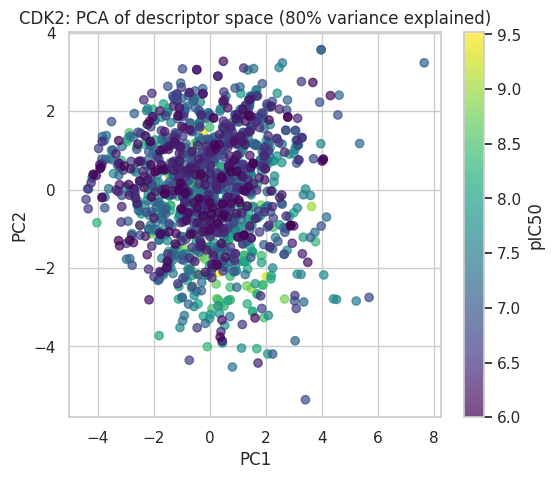

In [20]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

feature_cols = ["MW", "cLogP", "HBD", "HBA", "TPSA", "QED"]
potency_col = "pIC50" # adjust if your column name differs
pca_df = df.dropna(subset=[potency_col]).reset_index(drop=True)

X = StandardScaler().fit_transform(pca_df[feature_cols])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pca_df = pca_df.assign(PC1=X_pca[:, 0], PC2=X_pca[:, 1])

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(pca_df["PC1"], pca_df["PC2"], c=pca_df[potency_col], cmap="viridis",
        alpha=0.7)
plt.colorbar(sc, ax=ax, label=potency_col)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"{TARGET_NAME}: PCA of descriptor space ({pca.explained_variance_ratio_.
        sum():.0%} variance explained)")
fig.savefig(ANALYSIS_DIR / f"{TARGET_NAME}_pca_descriptor_space.png", dpi=150,
        bbox_inches="tight")
plt.show()

QSAR model

R^2: 0.1380939830838661
RMSE: 0.7420513716895817


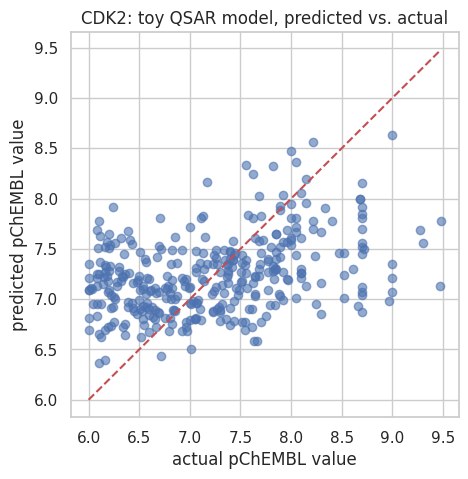

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

model_df = df.dropna(subset=[potency_col])

X = model_df[feature_cols].values
y = model_df[potency_col].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state
                                                    =0)
rf = RandomForestRegressor(n_estimators=300, random_state=0)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

print("R^2:", r2_score(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, pred, alpha=0.6)
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
ax.plot(lims, lims, "r--")
ax.set_xlabel("actual pChEMBL value")
ax.set_ylabel("predicted pChEMBL value")
ax.set_title(f"{TARGET_NAME}: toy QSAR model, predicted vs. actual")
fig.savefig(ANALYSIS_DIR / f"{TARGET_NAME}_qsar_predicted_vs_actual.png", dpi=150,
            bbox_inches="tight")
plt.show()